In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving abalone.csv to abalone.csv


In [ ]:
abalone = pd.read_csv('abalone.csv')

In [ ]:
abalone.head()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [ ]:
abalone.tail()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [ ]:
abalone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [ ]:
abalone.describe()

,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [ ]:
abalone.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
       'Viscera weight', 'Shell weight', 'Rings'],
      dtype='object')

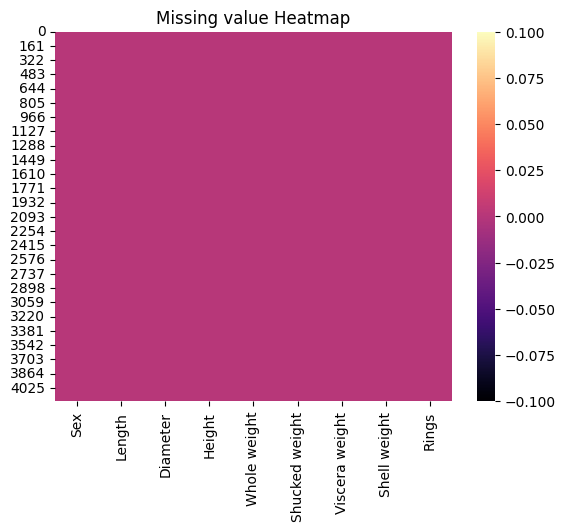

In [ ]:
sns.heatmap(abalone.isnull(),cmap='magma')
plt.title("Missing value Heatmap")
plt.show()

In [ ]:
abalone.isnull()

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
4172,False,False,False,False,False,False,False,False,False
4173,False,False,False,False,False,False,False,False,False
4174,False,False,False,False,False,False,False,False,False
4175,False,False,False,False,False,False,False,False,False


In [ ]:
abalone.duplicated().sum()

np.int64(0)

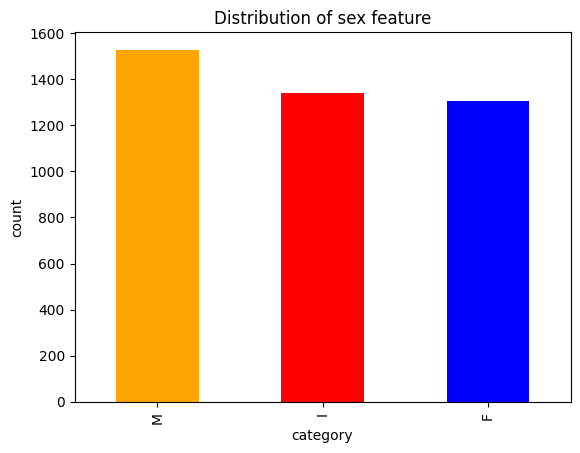

In [ ]:
abalone['Sex'].value_counts().plot(kind = 'bar',color = ['orange','red','blue'])
plt.title("Distribution of sex feature")
plt.xlabel("category")
plt.ylabel("count")
plt.show()

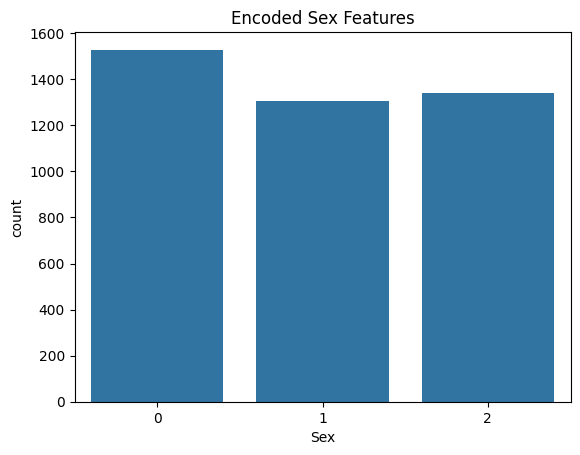

In [ ]:
abalone['Sex']= abalone['Sex'].map({"M":0,"F":1,"I":2})
sns.countplot(x='Sex', data=abalone)
plt.title("Encoded Sex Features")
plt.show()

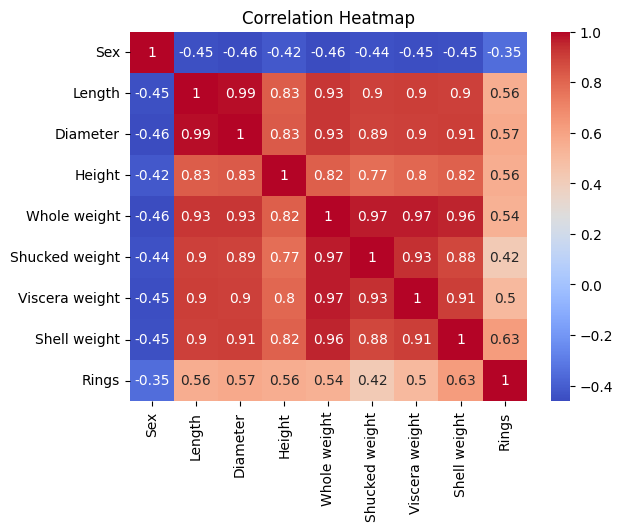

In [ ]:
corr = abalone.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

ring is our target variable

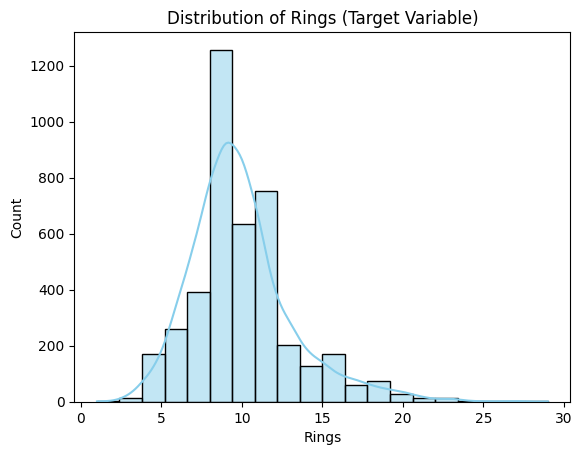

In [ ]:
sns.histplot(abalone['Rings'],bins=20, kde=True, color='skyblue')
plt.title("Distribution of Rings (Target Variable)")
plt.show()

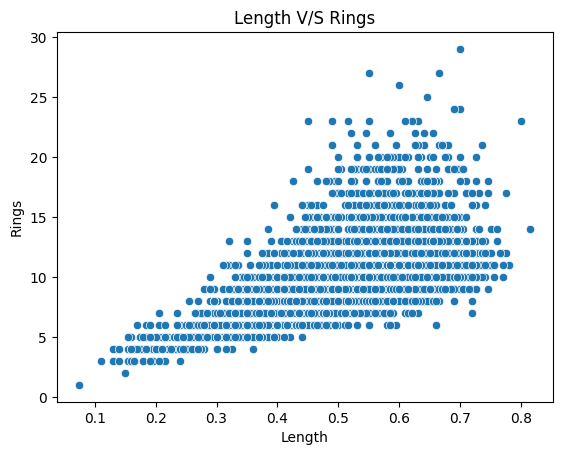

In [ ]:
sns.scatterplot(x='Length',y='Rings',data=abalone)
plt.title("Length V/S Rings")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = abalone.drop("Rings", axis = 1)
y = abalone['Rings']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

models = [
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge()),
    ('Decision Tree', DecisionTreeRegressor(random_state=42)),
    ('Random Forest', RandomForestRegressor(random_state=42))
]

results = {}
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results[name] = r2
    print(f'{name}: MSE = {mse:.2f}, R2 = {r2:.2f}')

Linear Regression: MSE = 4.95, R2 = 0.54
Ridge Regression: MSE = 4.99, R2 = 0.54
Decision Tree: MSE = 9.02, R2 = 0.17
Random Forest: MSE = 5.07, R2 = 0.53


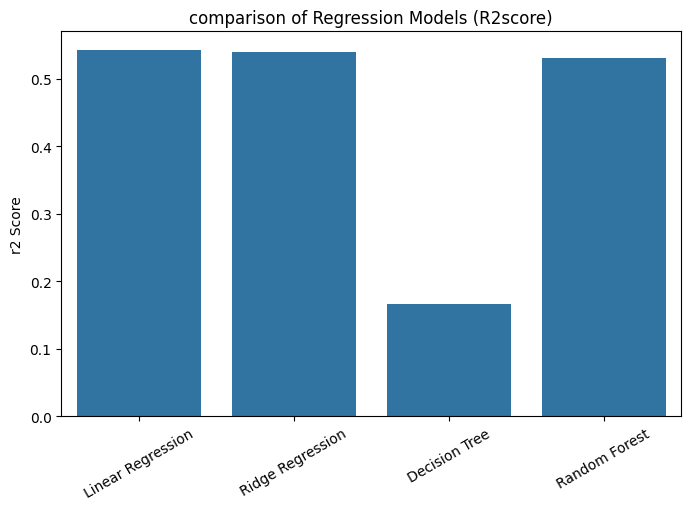

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()),y=list(results.values()))
plt.title("comparison of Regression Models (R2score)")
plt.ylabel("r2 Score")
plt.xticks(rotation=30)
plt.show()

In [ ]:
dtr = DecisionTreeRegressor()
dtr.fit(X_train,y_train)
y_pred = dtr.predict(X_test)
print("Decision Tree MSE:", mean_squared_error(y_test,y_pred))
print("Decision Tree R2Score:",r2_score(y_test,y_pred))

Decision Tree MSE: 9.572966507177034
Decision Tree R2Score: 0.11567845179082004


In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
print("Random Forest MSE:", mean_squared_error(y_test,y_pred))
print("Random Forest R2Score:",r2_score(y_test,y_pred))


Random Forest MSE: 5.007573564593302
Random Forest R2Score: 0.5374155749847733


In [ ]:
def prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight):
    features = np.array([[Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight]])
    pred = dtr.predict(features).reshape(1, -1)
    return pred[0]

In [ ]:
Sex = 2
Length = 0.6
Diameter = 0.45
Height = 0.15
Whole_weight = 1.2
Shucked_weight = 0.6
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [12.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
Sex = 1
Length = 0.8
Diameter = 0.50
Height = 0.25
Whole_weight = 1.1
Shucked_weight = 0.4
Viscera_weight = 0.3
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)

Predicted Rings (Age): [18.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
Sex = 0
Length = 0.9
Diameter = 0.90
Height = 0.30
Whole_weight = 1.7
Shucked_weight = 0.8
Viscera_weight = 0.5
Shell_weight = 0.4

prediction = prediction_age(Sex, Length, Diameter, Height, Whole_weight, Shucked_weight, Viscera_weight, Shell_weight)
print("Predicted Rings (Age):", prediction)


Predicted Rings (Age): [10.]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pickle

pickle.dump(model, open('model.pkl', 'wb'))

In [ ]:
pip install flask

In [ ]:
from flask import Flask, request, render_template
import pickle
import numpy as np

app = Flask(__name__)

model = pickle.load(open('model.pkl', 'rb'))

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    features = [float(x) for x in request.form.values()]
    final_features = [np.array(features)]

    prediction = model.predict(final_features)

    return render_template('index.html', prediction_text=f"Prediction: {prediction[0]}")

if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with watchdog (inotify)


In [ ]:
python app.py